In [2]:
%matplotlib inline
import sys
sys.path.append('../functions')
import numpy as np
#import statsmodels.api as sm
from sklearn.linear_model import LinearRegression
#import torch
import pandas as pd
import multiprocessing
import time
from sklearn.model_selection import ParameterGrid
import linear_sim_func  

In [3]:
!python3 ../functions/main_linear.py

Runtime of the program is 0.10036563873291016 seconds


# One simulation 

In [2]:
N_v = [60]
N_test_v = [500]
p_v = [40]
error_sd_v = [1]
L_v = [0.9]
level_v = [0.2]
use_true_contour_v = [True]
n_boot_v = [2000]
ridge_penal_v = [[1,0.5,1e-1, 1e-2, 1e-3, 1e-4]]
#ridge_penal_v = [None]
MC_v = [False]
second_stage_v = [False]
center_G_v = [True]
center_pred_v = [True]
residual_boot_v = [False]
CV_boot_v = [True]
df_result = []
param_grid = {'N': N_v, 'N_test': N_test_v, 'p': p_v , 'error_sd': error_sd_v, 'L': L_v,
              'level': level_v,  'use_true_contour': use_true_contour_v, 'n_boot':n_boot_v,
              'ridge_penal':ridge_penal_v, 'MC':MC_v, 'second_stage':second_stage_v,
              'center_G':center_G_v, 'center_pred':center_G_v,
              'residual_boot':residual_boot_v, 'CV_boot':CV_boot_v}
param_grid = ParameterGrid(param_grid)
for param in param_grid:
    l = linear_sim_func.sim_linear(param['N'], param['N_test'], param['p'], param['error_sd'], 
                          param['L'],param['level'],param['use_true_contour'], param['n_boot'], 
                            param['ridge_penal'], param['MC'], param['second_stage'], 
                            param['center_G'], param['center_pred'], 
                            param['residual_boot'], param['CV_boot'])

> /Users/juntingren/Desktop/prediction_uncertainty/functions/confidence_set_func.py(48)process_boot_samples()
     46     '''
     47     import pdb; pdb.set_trace()
---> 48     if MC:
     49         G = (mean_boot_l-mean_test_true)/se
     50     elif second_stage:



ipdb>  mean_boot_l.shape


(2000, 500)


ipdb>  n


> /Users/juntingren/Desktop/prediction_uncertainty/functions/confidence_set_func.py(50)process_boot_samples()
     48     if MC:
     49         G = (mean_boot_l-mean_test_true)/se
---> 50     elif second_stage:
     51         mean_matrix, se = second_stage_boot(mean_boot_l)
     52         mean = np.mean(mean_boot_l, axis = 0)



...

> /Users/juntingren/Desktop/prediction_uncertainty/functions/confidence_set_func.py(61)process_boot_samples()
     59             G = (mean_boot_l-mean)/se
     60         if center_pred:
---> 61             mean = np.mean(mean_boot_l, axis = 0)
     62     return G, mean, se
     63 



ipdb>  n


> /Users/juntingren/Desktop/prediction_uncertainty/functions/confidence_set_func.py(62)process_boot_samples()
     60         if center_pred:
     61             mean = np.mean(mean_boot_l, axis = 0)
---> 62     return G, mean, se
     63 
     64 class cal_thres_at_q(object):



ipdb>  q


BdbQuit: 

In [ ]:
l

In [26]:
mae

0.610364083223544

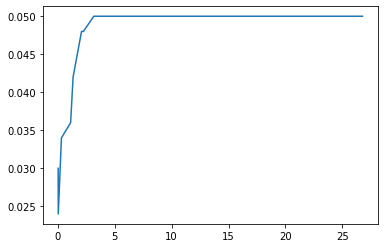

0.9500000000000028
0.974
True
0.752
0.9500000000000028
0.974
0.982
2


In [10]:
from matplotlib import pyplot as plt
x = [z[0] for z in range_v]
y = [z[1] for z in range_v]
plt.plot(x,y)
plt.show()
print(L)
print(U)
print(contain)
print(L1)
print(L2)
print(U1)
print(U2)
print(n_points)

# Bootstrap quantile vs True quantile

In [2]:
import bootstrap_func
from linear_sim_func import *
import matplotlib.pyplot as plt
from sklearn.linear_model import RidgeCV
import confidence_set_func
# bootstrap
N_test = 500
p = 40
beta =None
error_sd = 1
X_test = None
n_boot = 2000
smoothed = False
residual_boot = False
sparsity = 0
#bias_correction = True
if beta is None:
    rng = np.random.default_rng(None)
    beta = rng.standard_normal(size = p)
    if sparsity > 0:
        index_zero = rng.choice(range(p), size= int(p*sparsity))
        beta[index_zero] = 0
y,X, X_test, mean_test_true = generate_linear_data(N = 100, N_test = N_test, p = p,beta = beta, error_sd = error_sd, X_test = X_test)
penal_sizes = [1,0.5,1e-1, 1e-2, 1e-3, 1e-4]

In [268]:
N = 100
ridge_penal = True
CV_boot = True
second_stage = False
n_sample_mean = 100
boot_sample_ratio = 1

In [269]:
y,X, _, _ = generate_linear_data(N = N, N_test = N_test, p = p,beta = beta, error_sd = error_sd, X_test = X_test)
if ridge_penal is not None:
    mean, se, mean_boot_l, mean_train = bootstrap_func.fit_bootstrap_ridge(y = y, 
                                          X = X, X_test = X_test, n_boot = n_boot,  penal_sizes = penal_sizes, 
                                                               residual_boot = residual_boot, CV_boot = CV_boot, boot_sample_ratio = boot_sample_ratio)
else:# linear model without penality
    mean, se, mean_boot_l,mean_train = bootstrap_func.fit_bootstrap( y = y, 
                                          X = X, X_test = X_test, n_boot = n_boot,residual_boot =  residual_boot, boot_sample_ratio = boot_sample_ratio)
if second_stage:
    #mean = np.mean(mean_boot_l, axis = 0)
    mean_boot_l, se = confidence_set_func.second_stage_boot(mean_boot_l, n_sample = n_sample_mean)
mean_bias_cor1 = 2*mean - np.mean(mean_boot_l, axis = 0)
mean_bias_cor2 = mean - np.mean(mean_train - y)
# MCMC    
mean_MC_l = []
if second_stage:
    for i in range(n_boot):
        mean_MC_l_2 = []
        for j in range(n_sample_mean):
            y_new,X_new, X_test_trash, mean_test_true_trash = generate_linear_data(N = N, N_test = N_test, p = p,beta = beta, error_sd = error_sd, X_test = X_test)
            if ridge_penal is not None:
                if CV_boot:
                    clf = RidgeCV(alphas = penal_sizes, store_cv_values = True).fit(X_new, y_new)
                    mean_MC_l_2.append(clf.predict(X_test))
                else:
                    mean_MC_l_2.append(ridge_linear_fit_predict(y_new, X_new, X_test, ridge_penal) )
            else:# linear model without penality
                mean_MC_l_2.append(linear_fit_predict(y_new, X_new, X_test) )
        mean_MC_l.append(np.mean(mean_MC_l_2, axis = 0))
else:
    for i in range(n_boot):
        y_new,X_new, X_test_trash, mean_test_true_trash = generate_linear_data(N = N, N_test = N_test, p = p,beta = beta, error_sd = error_sd, X_test = X_test)
        if ridge_penal is not None:
            if CV_boot:
                clf = RidgeCV(alphas = penal_sizes, store_cv_values = True).fit(X_new, y_new)
                mean_MC_l.append(clf.predict(X_test))
            else:
                mean_MC_l.append(ridge_linear_fit_predict(y_new, X_new, X_test, ridge_penal) )
        else:# linear model without penality
            mean_MC_l.append(linear_fit_predict(y_new, X_new, X_test) )
mean_MC_l = np.array(mean_MC_l)
se_MC = np.std(mean_MC_l, axis = 0)
if smoothed:
    mean_MC = np.mean(mean_MC_l, axis = 0)
else:
    mean_MC = ridge_linear_fit_predict(y, X, X_test, ridge_penal) if ridge_penal is not None else linear_fit_predict(y, X, X_test) 

In [272]:
np.mean(np.abs(mean_train - y))

0.6574970453182513

In [274]:
use_a_true = False
a_true = np.quantile(np.max(np.abs((mean_MC_l - mean_test_true)/se_MC),axis = 1), q = 0.975)
print(a_true)
minus_mean = np.mean(mean_boot_l, axis = 0)
#minus_mean = mean
a = np.quantile(np.max(np.abs((mean_boot_l - minus_mean)/se),axis = 1), q = 0.975)
print(a)
est = mean
#est = mean_bias_cor1
if use_a_true:
    print(np.all(np.logical_and(est+a_true*se>mean_test_true, est - a_true*se < mean_test_true)))
else:
    print(np.all(np.logical_and(est+a*se>mean_test_true, est - a*se < mean_test_true)))

4.2063835426680445
4.556983729558617
True


In [277]:
print(np.mean(se_MC-se))
print(np.mean(a_true*se_MC-a*se))

-0.27345755818815404

1.2957515141799538
0.8950762572197092
2.3787614290998125
1.2871423290622537
0.9695342915423788
0.8565128772165557
8.400686037251324
9.006343490454078
1.0457946682591461
0.7550048975019438
2.405159169226389
1.5712198770765626
1.1852329253406007
0.7952089240577825
3.620872194488976
2.2443027037935517
1.2957515141799538
0.8950762572197092
2.3787614290998125
1.2871423290622537
1.0524161389741682
0.8865403506436713
5.099933517105743
5.21341545582265
1.1506264070099832
0.6197999243534548
2.1362314177256603
0.9935941810359927
0.972542224359687
0.6954608515341517
18.39496254123537
17.887589565918233


/tmp/ipykernel_1058/710432529.py:33: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()
/tmp/ipykernel_1058/710432529.py:66: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


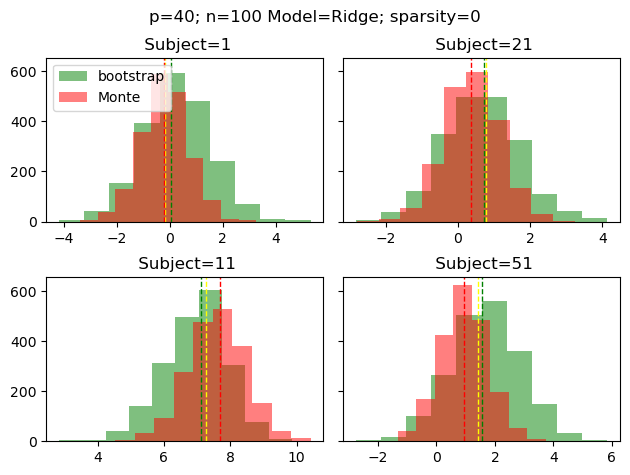

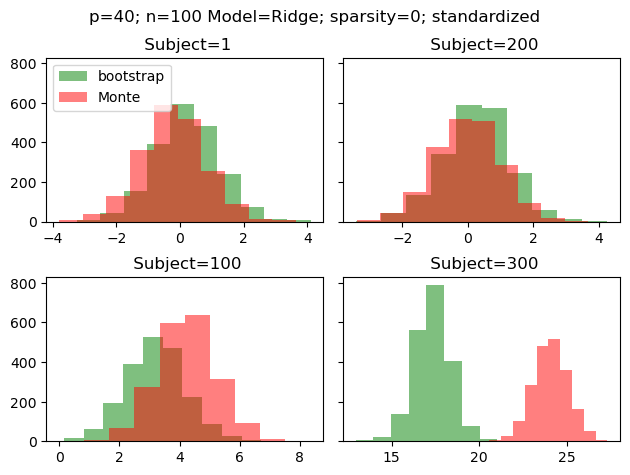

In [289]:
fig, axs = plt.subplots(2, 2, sharex = False, sharey = True)
j = 0
for i in (1,11,21,51):
    if j==0:
        q1, q2 = 0,0
    elif j==1:
        q1,q2 =1,0
    elif j==2:
        q1,q2 = 0,1
    else:
        q1,q2 = 1,1
    axs[q1,q2].hist(mean_boot_l[:,i], color = 'green', alpha=0.5, label = 'bootstrap')
    axs[q1,q2].hist(mean_MC_l[:,i], color = 'red', alpha=0.5, label = 'Monte')
    axs[q1,q2].axvline(mean[i], color='green', linestyle='dashed', linewidth=1)
    axs[q1,q2].axvline(mean_bias_cor1[i], color='yellow', linestyle='dashed', linewidth=1)
    #axs[q1,q2].axvline(mean_bias_cor1[i], color='yellow', linestyle='dashed', linewidth=1)
    axs[q1,q2].axvline(mean_test_true[i], color='red', linestyle='dashed', linewidth=1)
    axs[q1,q2].set_title(' Subject='+str(i))
    if j==0:
        axs[q1,q2].legend(loc="upper left")
    print(np.std(mean_boot_l[:,i]))
    print(np.std(mean_MC_l[:,i]))
    print(np.quantile(mean_boot_l[:,i], q = 0.95))
    print(np.quantile(mean_MC_l[:,i], q = 0.95))
    j += 1
title = 'p='+str(p)+'; n='+str(N)+'; Model='+'linear' if ridge_penal is None else 'p='+str(p)+'; n='+str(N)+' Model='+'Ridge'
title = title+'; sparsity='+str(sparsity)
if second_stage:
    title = 'Second stage boot; '+ title
fig.tight_layout()
fig.subplots_adjust(top=0.88)
fig.suptitle(title)
fig.show()
#fig.savefig('../results/'+title+'.png')


fig, axs = plt.subplots(2, 2, sharex = False, sharey = True)
j = 0
for i in (1,100,200,300):
    if j==0:
        q1, q2 = 0,0
    elif j==1:
        q1,q2 =1,0
    elif j==2:
        q1,q2 = 0,1
    else:
        q1,q2 = 1,1
    axs[q1,q2].hist(mean_boot_l[:,i]/se[i], color = 'green', alpha=0.5, label = 'bootstrap')
    axs[q1,q2].hist(mean_MC_l[:,i]/se_MC[i], color = 'red', alpha=0.5, label = 'Monte')
    # axs[q1,q2].axvline(mean[i], color='green', linestyle='dashed', linewidth=1)
    # #plt.axvline(mean_bias_cor[i], color='green', linestyle='dashed', linewidth=1)
    # axs[q1,q2].axvline(mean_test_true[i], color='red', linestyle='dashed', linewidth=1)
    axs[q1,q2].set_title(' Subject='+str(i))
    if j==0:
        axs[q1,q2].legend(loc="upper left")
    print(np.std(mean_boot_l[:,i]))
    print(np.std(mean_MC_l[:,i]))
    print(np.quantile(mean_boot_l[:,i], q = 0.95))
    print(np.quantile(mean_MC_l[:,i], q = 0.95))
    j += 1
title = 'p='+str(p)+'; n='+str(N)+'; Model='+'linear' if ridge_penal is None else 'p='+str(p)+'; n='+str(N)+' Model='+'Ridge'
title = title+'; sparsity='+str(sparsity)+'; standardized'
fig.tight_layout()
fig.subplots_adjust(top=0.88)
fig.suptitle(title)
fig.show()
#fig.savefig('../results/'+title+'.png')

# G = (mean_boot_l-np.mean(mean_boot_l,axis = 0))/se
# #np.mean(mean_boot_l,axis = 0)
# G_MC = (mean_MC_l-mean_test_true)/se_MC
# plt.hist(G[:,i], color = 'yellow', alpha=0.5)
# plt.hist(G_MC[:,i], color = 'red', alpha=0.5)
# plt.show()
# print(np.std(G[:,i]))
# print(np.std(G_MC[:,i]))
# print(np.quantile(G[:,i], q = 0.95))
# print(np.quantile(G_MC[:,i], q = 0.95))
# print(np.quantile(G[:,i], q = 0.1))
# print(np.quantile(G_MC[:,i], q = 0.1))
# print(np.quantile(np.abs(G[:,i]), q = 0.95))
# print(np.quantile(np.abs(G_MC[:,i]), q = 0.95))
# print(np.quantile(np.abs(G[:,i]), q = 0.1))
# print(np.quantile(np.abs(G_MC[:,i]), q = 0.1))

# Neural nets

In [48]:
%matplotlib inline
import sys
sys.path.append('../functions')
import bootstrap_func
from NN_sim_func import *
import matplotlib.pyplot as plt
import confidence_set_func
import neural_net_func
# bootstrap
N_test = 500
p = 1
beta =None
error_sd = 1
X_test = None
n_boot = 1000
#bias_correction = True
if beta is None:
    rng = np.random.default_rng(None)
    beta = rng.standard_normal(size = p*3)
X, y, X_test, y_test, mean_test_true = generate_NN_data(100, N_test, p,  transform_X_poly, beta=beta, error_sd = 1, seed = None, X = None, X_test = None, if_tensor = True)


In [49]:
N = 100
input_size = p
h_sizes = [5,5]
out_size= 1
n_iter = 100
lr = 0.01
device = 'cpu'
patience = 10
weight_decay = 0
second_stage = False
n_sample_mean = 100

In [50]:
X.shape

torch.Size([100, 1])

In [51]:
X, y, _, _, _, beta = generate_NN_data(N, N_test, p,  transform_X_poly, beta=beta, error_sd = 1, seed = None, X = None, X_test = None, if_tensor = True)
mean, se, mean_boot_l,mean_train = bootstrap_func.fit_bootstrap_NN(y, X, X_test, input_size, h_sizes, out_size,
                  n_boot, n_iter, lr, device, patience, weight_decay, batchnorm_ind = False)
if second_stage:
    #mean = np.mean(mean_boot_l, axis = 0)
    mean_boot_l, se = confidence_set_func.second_stage_boot(mean_boot_l, n_sample = n_sample_mean)
mean_bias_cor1 = 2*mean - np.mean(mean_boot_l, axis = 0)
mean_bias_cor2 = mean - np.mean(mean_train - y.numpy())
# MCMC    
mean_MC_l = []
if second_stage:
    for i in range(n_boot):
        mean_MC_l_2 = []
        for j in range(n_sample_mean):
            X_new,y_new, _, _,_,beta = generate_NN_data(N, N_test, p,  transform_X_poly, beta=beta, error_sd = 1, seed = None, X = None, X_test = None, if_tensor = True)
            model = neural_net_func.FF_neural_net(input_size = input_size, h_sizes = h_sizes, out_size = out_size, batchnorm_ind = False)
            mean_MC_l_2.append(neural_net_func.nn_fit_predict(model, y_new, X_new, X_test, n_iter = n_iter, lr = lr, device = device,  
                          patience = patience, weight_decay = weight_decay) )
        mean_MC_l.append(np.mean(mean_MC_l_2, axis = 0))
else:
    for i in range(n_boot):
        X_new, y_new, _, _,_,beta = generate_NN_data(N, N_test, p,  transform_X_poly, beta=beta, error_sd = 1, seed = None, X = None, X_test = None, if_tensor = True)
        model = neural_net_func.FF_neural_net(input_size = input_size, h_sizes = h_sizes, out_size = out_size, batchnorm_ind = False)
        mean_MC_l.append(neural_net_func.nn_fit_predict(model, y_new, X_new, X_test, n_iter = n_iter, lr = lr, device = device,  
                      patience = patience, weight_decay = weight_decay) )

mean_MC_l = np.array(mean_MC_l)
se_MC = np.std(mean_MC_l, axis = 0)
mean_MC = np.mean(mean_MC_l, axis = 0)

In [52]:
np.mean(np.abs(mean_train - y.numpy()))

0.8656596521872

In [53]:
use_a_true = False
a_true = np.quantile(np.max(np.abs((mean_MC_l - mean_test_true)/se_MC),axis = 1), q = 0.975)
print(a_true)
minus_mean = np.mean(mean_boot_l, axis = 0)
#minus_mean = mean
a = np.quantile(np.max(np.abs((mean_boot_l - minus_mean)/se),axis = 1), q = 0.975)
print(a)
est = mean
#est = mean_bias_cor1
if use_a_true:
    print(np.all(np.logical_and(est+a_true*se>mean_test_true, est - a_true*se < mean_test_true)))
else:
    print(np.all(np.logical_and(est+a*se>mean_test_true, est - a*se < mean_test_true)))

5.0817762959924195
3.8263748310146983
True


In [54]:
print(np.mean(se_MC-se))
print(np.mean(a_true*se_MC-a*se))

-0.0366139192196663
0.39189154540962695


0.3166425327632814
0.305133183507872
-0.6160915316706902
-0.7321069940766672
0.3600029097510402
0.37375303786188563
-1.3300759388441399
-1.4240326261389546
0.31621795287312876
0.305688193670781
-0.6203488041987554
-0.7390966349048067
0.3076608018128761
0.3167251875085307
-0.8174699029418598
-0.9042961474079528
0.3166425327632814
0.305133183507872
-0.6160915316706902
-0.7321069940766672
0.5104851534613131
0.4501640820608175
-0.38430806135707324
-0.2502636195816642
0.3298668114526479
0.26114835826097904
-0.15563393306469706
-0.3795619144016865
0.30716569719587317
0.32445224423118096
-0.9586410894954118
-1.0523844562343574


/Users/juntingren/opt/anaconda3/envs/deeplearning/lib/python3.7/site-packages/ipykernel_launcher.py:33: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
/Users/juntingren/opt/anaconda3/envs/deeplearning/lib/python3.7/site-packages/ipykernel_launcher.py:66: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.


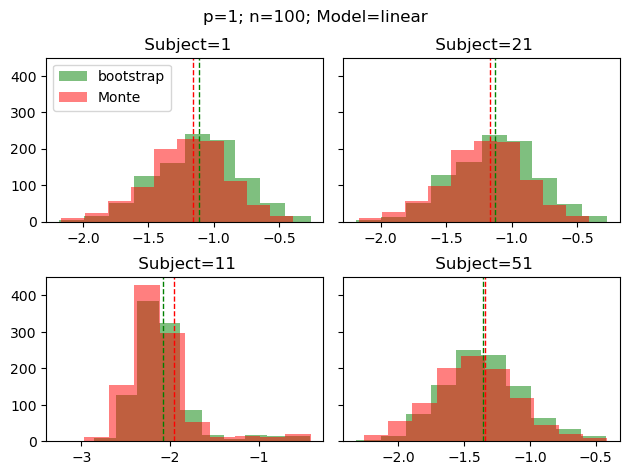

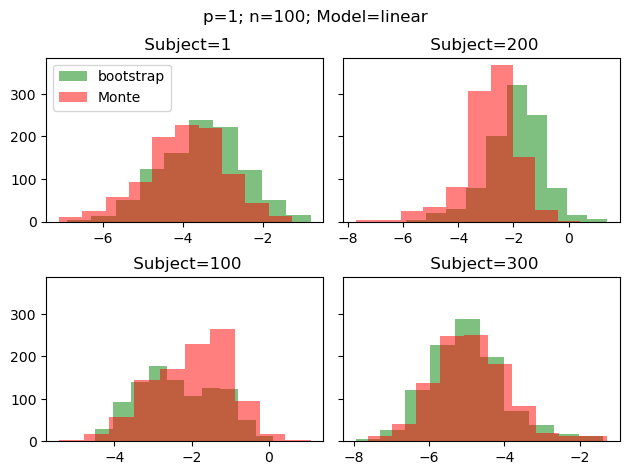

In [55]:
fig, axs = plt.subplots(2, 2, sharex = False, sharey = True)
j = 0
for i in (1,11,21,51):
    if j==0:
        q1, q2 = 0,0
    elif j==1:
        q1,q2 =1,0
    elif j==2:
        q1,q2 = 0,1
    else:
        q1,q2 = 1,1
    axs[q1,q2].hist(mean_boot_l[:,i], color = 'green', alpha=0.5, label = 'bootstrap')
    axs[q1,q2].hist(mean_MC_l[:,i], color = 'red', alpha=0.5, label = 'Monte')
    axs[q1,q2].axvline(mean[i], color='green', linestyle='dashed', linewidth=1)
    #axs[q1,q2].axvline(mean_bias_cor1[i], color='yellow', linestyle='dashed', linewidth=1)
    #axs[q1,q2].axvline(mean_bias_cor1[i], color='yellow', linestyle='dashed', linewidth=1)
    axs[q1,q2].axvline(mean_test_true[i], color='red', linestyle='dashed', linewidth=1)
    axs[q1,q2].set_title(' Subject='+str(i))
    if j==0:
        axs[q1,q2].legend(loc="upper left")
    print(np.std(mean_boot_l[:,i]))
    print(np.std(mean_MC_l[:,i]))
    print(np.quantile(mean_boot_l[:,i], q = 0.95))
    print(np.quantile(mean_MC_l[:,i], q = 0.95))
    j += 1
title = 'p='+str(p)+'; n='+str(N)+'; Model='+'linear' 
#title = title+'; sparsity='+str(sparsity)
if second_stage:
    title = 'Second stage boot; '+ title
fig.tight_layout()
fig.subplots_adjust(top=0.88)
fig.suptitle(title)
fig.show()
#fig.savefig('../results/'+title+'.png')


fig, axs = plt.subplots(2, 2, sharex = False, sharey = True)
j = 0
for i in (1,100,200,300):
    if j==0:
        q1, q2 = 0,0
    elif j==1:
        q1,q2 =1,0
    elif j==2:
        q1,q2 = 0,1
    else:
        q1,q2 = 1,1
    axs[q1,q2].hist(mean_boot_l[:,i]/se[i], color = 'green', alpha=0.5, label = 'bootstrap')
    axs[q1,q2].hist(mean_MC_l[:,i]/se_MC[i], color = 'red', alpha=0.5, label = 'Monte')
    # axs[q1,q2].axvline(mean[i], color='green', linestyle='dashed', linewidth=1)
    # #plt.axvline(mean_bias_cor[i], color='green', linestyle='dashed', linewidth=1)
    # axs[q1,q2].axvline(mean_test_true[i], color='red', linestyle='dashed', linewidth=1)
    axs[q1,q2].set_title(' Subject='+str(i))
    if j==0:
        axs[q1,q2].legend(loc="upper left")
    print(np.std(mean_boot_l[:,i]))
    print(np.std(mean_MC_l[:,i]))
    print(np.quantile(mean_boot_l[:,i], q = 0.95))
    print(np.quantile(mean_MC_l[:,i], q = 0.95))
    j += 1
title = 'p='+str(p)+'; n='+str(N)+'; Model='+'linear' 
#title = title+'; sparsity='+str(sparsity)+'; standardized'
fig.tight_layout()
fig.subplots_adjust(top=0.88)
fig.suptitle(title)
fig.show()
#fig.savefig('../results/'+title+'.png')

# G = (mean_boot_l-np.mean(mean_boot_l,axis = 0))/se
# #np.mean(mean_boot_l,axis = 0)
# G_MC = (mean_MC_l-mean_test_true)/se_MC
# plt.hist(G[:,i], color = 'yellow', alpha=0.5)
# plt.hist(G_MC[:,i], color = 'red', alpha=0.5)
# plt.show()
# print(np.std(G[:,i]))
# print(np.std(G_MC[:,i]))
# print(np.quantile(G[:,i], q = 0.95))
# print(np.quantile(G_MC[:,i], q = 0.95))
# print(np.quantile(G[:,i], q = 0.1))
# print(np.quantile(G_MC[:,i], q = 0.1))
# print(np.quantile(np.abs(G[:,i]), q = 0.95))
# print(np.quantile(np.abs(G_MC[:,i]), q = 0.95))
# print(np.quantile(np.abs(G[:,i]), q = 0.1))
# print(np.quantile(np.abs(G_MC[:,i]), q = 0.1))

In [61]:
!python3 ../functions/main_NN.py

Runtime of the program is 484.9861228466034 seconds
